In [35]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.hmc import multi_chain_hmc
from algorithms.mcmc import multi_chain_mcmc
from algorithms.nuts import nuts
from algorithms.svgd import svgd
from utilities.helpers import effective_sample_size,autocorr_new,gr_statistic

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())

[CpuDevice(id=0)]


In [36]:
beta_true = jnp.log(0.3)
gamma_true = jnp.log(0.1)

t_vec = jnp.linspace(0,100,100)

def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

In [37]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Euler(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [38]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
full_state = jnp.maximum(model(t_vec,jnp.array([100.,1.0,0.0]),(beta_true,gamma_true)),1e-6)

observations = jax.random.poisson(noise_key,full_state[:,1])


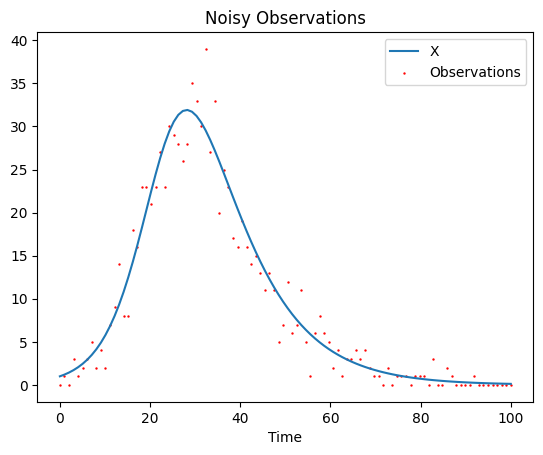

In [39]:
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,1],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [40]:
def log_likelihood(par):
    beta, gamma = par
    model_output = jnp.maximum(
        model(t_vec, jnp.array([100.0, 1.0, 0.0]), (beta, gamma)), 1e-6
    )
    return jnp.sum(
        jax.scipy.stats.poisson.logpmf(
            observations,
            model_output[:, 1],
        )
    )


def prior(par):
    beta, gamma = par
    return jax.scipy.stats.norm.logpdf(beta, 0.0, 1.0) + jax.scipy.stats.norm.logpdf(
        gamma, 0.0, 1.0
    )

@jax.jit
def joint(par):
    return log_likelihood(par) + prior(par)

In [41]:
D = 2
M = 1000
Madapt = 100
num_chains = 10
key = jax.random.key(0)
init_key, key = jax.random.split(key)

theta0 = jax.random.multivariate_normal(
    init_key,
    mean=jnp.log(jnp.array([0.1,0.1])),
    cov=jnp.eye(D),
    shape=(num_chains,),
)

func = jax.jit(jax.value_and_grad(joint))

In [42]:
hmc_key, key = jax.random.split(key)
t0 = perf_counter()
hmc_samples, lnprob = multi_chain_hmc(
    func,
    M,
    Madapt,
    theta0,
    key=hmc_key,
    mass_matrix=jnp.eye(D),
    epsilon=0.0005,
    L=50,
    num_chains=num_chains,
)
t1 = perf_counter()
print(f"Done. runtime {t1 - t0} seconds")
print(f"Effective sample size hmc: {effective_sample_size(hmc_samples)}")
print(f"The Gelman-Rubin statistic (r_hat): {gr_statistic(hmc_samples)}")

Done. runtime 31.93629812799918 seconds
Effective sample size hmc: [1358.2261   265.05362]
The Gelman-Rubin statistic (r_hat): [0.99920505 1.000172  ]


In [43]:
# mcmc_key, key = jax.random.split(key)
# t0 = perf_counter()
# mcmc_samples, lnprob = multi_chain_mcmc(
#     joint,
#     M,
#     Madapt,
#     theta0,
#     adaptive=True,
#     key=mcmc_key,
#     cov_matrix=jnp.eye(D),
#     num_chains=num_chains,
# )
# t1 = perf_counter()
# print(f"Done. runtime {t1 - t0} seconds")
# print(f"Effective sample size mcmc: {effective_sample_size(mcmc_samples)}")

In [44]:
# nuts_key, key = jax.random.split(key)
# M_nuts = M * num_chains
# t0 = perf_counter()
# nuts_samples, lnprob = nuts(
#     func,
#     M_nuts,
#     Madapt,
#     jnp.log(jnp.array([0.1,0.1])),
#     key=nuts_key,
#     epsilon = 0.001,
#     max_depth=5
# )
# t1 = perf_counter()
# print(f"Done. runtime {t1 - t0} seconds")
# print(f"Effective sample size nuts: {effective_sample_size(nuts_samples)}")


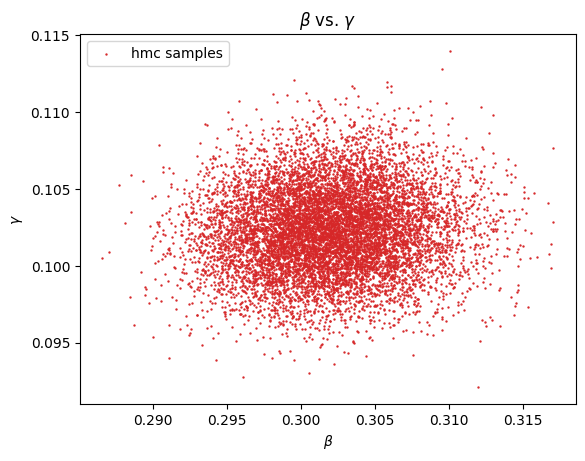

In [46]:

plt.title('$\\beta$ vs. $\\gamma$')
plt.xlabel('$\\beta$')
plt.ylabel("$\\gamma$")

#plt.scatter(jnp.exp(mcmc_samples[:,:,0]),jnp.exp(mcmc_samples[:,:,1]),s = 0.5,color = 'tab:blue',label = "mcmc samples")
plt.scatter(jnp.exp(hmc_samples[:,:,0]),jnp.exp(hmc_samples[:,:,1]),s = 0.5,color = 'tab:red',label = "hmc samples")
#plt.scatter(jnp.exp(nuts_samples[:,:,0]),jnp.exp(nuts_samples[:,:,1]),s = 0.5,color = 'tab:green',label = "nuts samples")

plt.legend()